# Learning the Robertson problem with ResNet and fixed-step Neural ODE baselines

This notebook is an **exploratory single-run Robertson learning experiment** for the thesis.

It is intentionally **not** a verdict on all Neural ODE methods for stiff systems. Instead, it studies:
- a **ResNet baseline**,
- a **fixed-step explicit Euler Neural ODE baseline**, and
- a **fixed-step explicit RK4 Neural ODE baseline**.

The point is to test whether these **simple explicit shared-flow baselines** remain viable in a genuinely stiff regime.

This notebook therefore emphasizes only Robertson-specific choices:
- the stiff Robertson kinetics,
- transformed-space training and evaluation,
- raw-space reconstruction diagnostics,
- and operator-evaluation accounting for this benchmark.


In [1]:
import os
import sys
import time
import math
import json
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## Reproducibility and CPU settings

In [2]:

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("device:", device)


device: cpu



## Experiment parameters
Data generation for Robertson is more expensive, hence this notebook is intentially smaller than damped oscillator or Van der Pol.

The default setup is designed to be a **reasonable first Robertson learning experiment**.


In [3]:
# ----------------------------
# User-adjustable parameters
# ----------------------------
T0, T1 = 0.0, 40.0
N_TIME = 81
T_EVAL = np.linspace(T0, T1, N_TIME)
DT = float(T_EVAL[1] - T_EVAL[0])

N_TRAIN = 128
N_VAL = 32
N_TEST = 32

# Dirichlet concentration for initial conditions on the simplex.
# This keeps y1 typically dominant, but still allows variation.
DIRICHLET_ALPHA = np.array([40.0, 2.0, 2.0])

BATCH_SIZE = 16
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-6

HIDDEN_DIM = 64
RESNET_BLOCKS = N_TIME - 1
NODE_HIDDEN_DIM = 64

TRUE_SOLVER_METHOD = "Radau"
TRUE_SOLVER_RTOL = 1e-10
TRUE_SOLVER_ATOL = 1e-12

EPS = 1e-12

MODEL_DISPLAY_NAMES = {
    "resnet": "ResNet",
    "node_euler": "NODE (Euler)",
    "node_rk4": "NODE (RK4)",
}

RESULTS_DIR = Path("results/learning/robertson")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DT =", DT)


DT = 0.5


In [4]:
run_metadata = {
    "system": "robertson",
    "seed": SEED,
    "single_run": True,
    "device": str(device),
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scipy_version": scipy.__version__,
    "ground_truth_solver": {
        "method": TRUE_SOLVER_METHOD,
        "rtol": TRUE_SOLVER_RTOL,
        "atol": TRUE_SOLVER_ATOL,
        "t0": T0,
        "t1": T1,
        "n_time": N_TIME,
        "t_eval": T_EVAL.tolist(),
    },
    "training_hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "hidden_dim": HIDDEN_DIM,
        "node_hidden_dim": NODE_HIDDEN_DIM,
        "resnet_blocks": RESNET_BLOCKS,
    },
    "accounting_note": (
        "operator_evals_per_trajectory counts one residual-block application for the ResNet "
        "and one vector-field evaluation for the Neural ODE baselines. "
        "total_fit_forward_evals counts training-set forward evaluations only; "
        "validation-time forward evaluations during model selection are reported separately."
    ),
    "study_note": (
        "This notebook focuses on straightforward fixed-step explicit baselines in a stiff regime. "
        "It is exploratory and should not be interpreted as a verdict on all Neural ODE methods for stiff systems."
    ),
}

with open(RESULTS_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

run_metadata


{'system': 'robertson',
 'seed': 42,
 'single_run': True,
 'device': 'cpu',
 'python_version': '3.10.10',
 'platform': 'macOS-26.4-arm64-arm-64bit',
 'torch_version': '2.11.0',
 'numpy_version': '1.26.4',
 'pandas_version': '2.3.3',
 'scipy_version': '1.15.3',
 'ground_truth_solver': {'method': 'Radau',
  'rtol': 1e-10,
  'atol': 1e-12,
  't0': 0.0,
  't1': 40.0,
  'n_time': 81,
  't_eval': [0.0,
   0.5,
   1.0,
   1.5,
   2.0,
   2.5,
   3.0,
   3.5,
   4.0,
   4.5,
   5.0,
   5.5,
   6.0,
   6.5,
   7.0,
   7.5,
   8.0,
   8.5,
   9.0,
   9.5,
   10.0,
   10.5,
   11.0,
   11.5,
   12.0,
   12.5,
   13.0,
   13.5,
   14.0,
   14.5,
   15.0,
   15.5,
   16.0,
   16.5,
   17.0,
   17.5,
   18.0,
   18.5,
   19.0,
   19.5,
   20.0,
   20.5,
   21.0,
   21.5,
   22.0,
   22.5,
   23.0,
   23.5,
   24.0,
   24.5,
   25.0,
   25.5,
   26.0,
   26.5,
   27.0,
   27.5,
   28.0,
   28.5,
   29.0,
   29.5,
   30.0,
   30.5,
   31.0,
   31.5,
   32.0,
   32.5,
   33.0,
   33.5,
   34.0,
   34.5


## True Robertson system and state transforms

The Robertson system is
\[
\begin{aligned}
\dot y_1 &= -0.04 y_1 + 10^4 y_2 y_3, \\
\dot y_2 &= 0.04 y_1 - 10^4 y_2 y_3 - 3\times 10^7 y_2^2, \\
\dot y_3 &= 3\times 10^7 y_2^2.
\end{aligned}
\]

Use the transformation
\[
u = \log_{10}(y + \varepsilon)
\]
componentwise for training.

This is a **practical modeling choice**, not a claim that the dynamics are fundamentally logarithmic.
It helps because the concentrations evolve on very different numerical scales.


In [5]:
def robertson(t, y):
    y1, y2, y3 = y
    dy1 = -0.04 * y1 + 1.0e4 * y2 * y3
    dy2 =  0.04 * y1 - 1.0e4 * y2 * y3 - 3.0e7 * y2**2
    dy3 =  3.0e7 * y2**2
    return np.array([dy1, dy2, dy3], dtype=np.float64)

def solve_true_trajectory(y0, t_eval=T_EVAL):
    sol = solve_ivp(
        fun=robertson,
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=np.asarray(y0, dtype=np.float64),
        t_eval=t_eval,
        method=TRUE_SOLVER_METHOD,
        rtol=TRUE_SOLVER_RTOL,
        atol=TRUE_SOLVER_ATOL,
    )
    if not sol.success:
        raise RuntimeError(f"Trajectory generation failed: {sol.message}")
    return sol.y.T.astype(np.float32)  # (time, state_dim)

def forward_transform(y):
    return np.log10(np.clip(y, 0.0, None) + EPS)

def inverse_transform(u):
    return np.maximum(10.0**u - EPS, 0.0)


## Sample initial conditions and build datasets

In [6]:

def sample_initial_conditions(n, alpha=DIRICHLET_ALPHA):
    ys = np.random.dirichlet(alpha=alpha, size=n).astype(np.float32)
    return ys

def make_dataset(n_samples):
    y0_raw = sample_initial_conditions(n_samples)
    traj_raw = np.stack([solve_true_trajectory(y0) for y0 in y0_raw], axis=0)

    y0_log = forward_transform(y0_raw)
    traj_log = forward_transform(traj_raw)

    return y0_raw, y0_log.astype(np.float32), traj_raw.astype(np.float32), traj_log.astype(np.float32)

train_y0_raw, train_y0_log, train_traj_raw, train_traj_log = make_dataset(N_TRAIN)
val_y0_raw, val_y0_log, val_traj_raw, val_traj_log = make_dataset(N_VAL)
test_y0_raw, test_y0_log, test_traj_raw, test_traj_log = make_dataset(N_TEST)

print("train raw:", train_y0_raw.shape, train_traj_raw.shape)
print("train log:", train_y0_log.shape, train_traj_log.shape)
print("val raw:  ", val_y0_raw.shape, val_traj_raw.shape)
print("test raw: ", test_y0_raw.shape, test_traj_raw.shape)


train raw: (128, 3) (128, 81, 3)
train log: (128, 3) (128, 81, 3)
val raw:   (32, 3) (32, 81, 3)
test raw:  (32, 3) (32, 81, 3)


## Visualize a few ground-truth trajectories

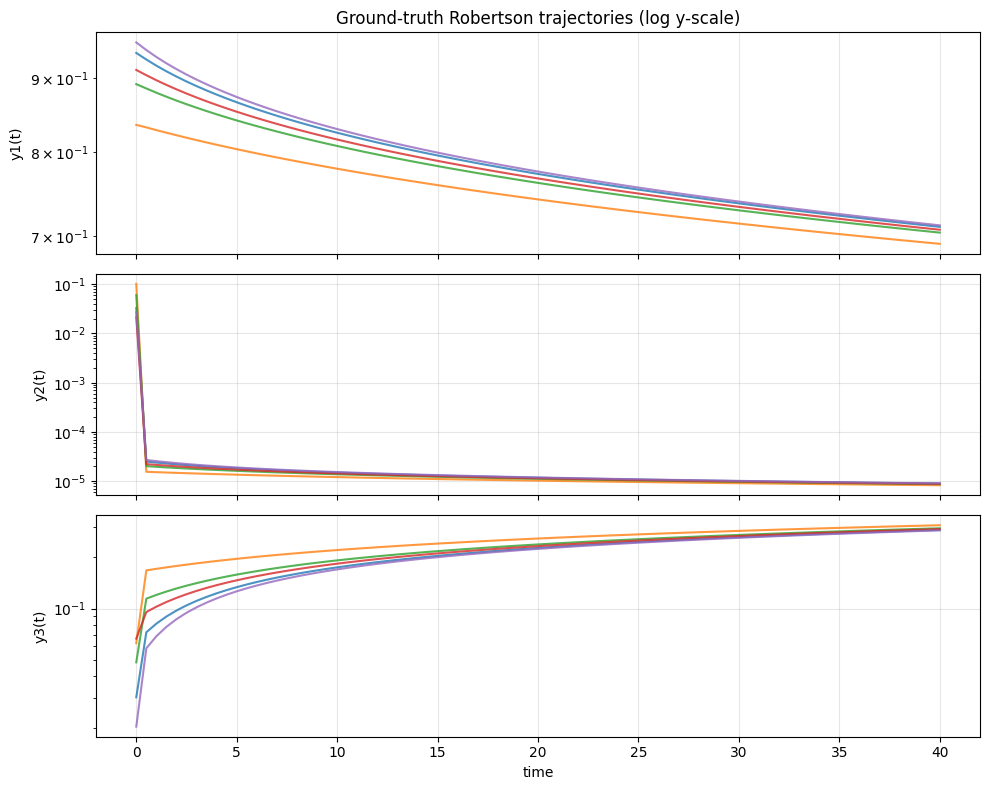

In [7]:

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i in range(min(5, N_TRAIN)):
    for j in range(3):
        axes[j].plot(T_EVAL, train_traj_raw[i, :, j], alpha=0.8)

labels = ["y1(t)", "y2(t)", "y3(t)"]
for j in range(3):
    axes[j].set_ylabel(labels[j])
    axes[j].set_yscale("log")
    axes[j].grid(True, alpha=0.3)

axes[0].set_title("Ground-truth Robertson trajectories (log y-scale)")
axes[-1].set_xlabel("time")

plt.tight_layout()
plt.show()


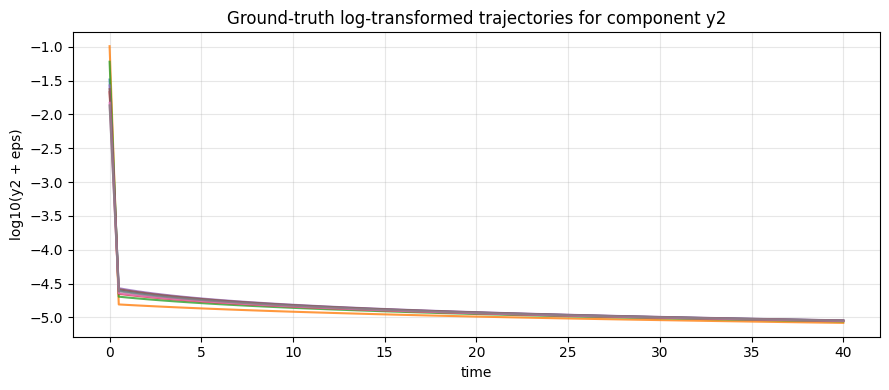

In [8]:

plt.figure(figsize=(9, 4))
for i in range(min(8, N_TRAIN)):
    plt.plot(T_EVAL, train_traj_log[i, :, 1], alpha=0.8)
plt.title("Ground-truth log-transformed trajectories for component y2")
plt.xlabel("time")
plt.ylabel("log10(y2 + eps)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Data loaders

In [9]:

train_ds = TensorDataset(torch.from_numpy(train_y0_log), torch.from_numpy(train_traj_log))
val_ds = TensorDataset(torch.from_numpy(val_y0_log), torch.from_numpy(val_traj_log))
test_ds = TensorDataset(torch.from_numpy(test_y0_log), torch.from_numpy(test_traj_log))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)



## Models

All models take a **log-transformed initial state** and predict the full **log-transformed trajectory** on the fixed grid `T_EVAL`.

### ResNet baseline
A discrete-depth model with untied residual blocks:
\[
u_{k+1} = u_k + F_k(u_k).
\]

### Neural ODE models
A learned vector field in transformed state space:
\[
\dot u(t) = f_\theta(u(t)),
\]
realized numerically with either:
- Euler,
- RK4.


In [10]:

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=2, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(self, state_dim=3, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return z + DT * self.f(z)


class ResNetTrajectoryModel(nn.Module):
    def __init__(self, num_blocks=RESNET_BLOCKS, state_dim=3, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([
            ResidualBlock(state_dim=state_dim, hidden_dim=hidden_dim)
            for _ in range(num_blocks)
        ])

    def forward(self, z0):
        zs = [z0]
        z = z0
        for block in self.blocks:
            z = block(z)
            zs.append(z)
        return torch.stack(zs, dim=1)


class VectorField(nn.Module):
    def __init__(self, state_dim=3, hidden_dim=NODE_HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return self.f(z)


class FixedStepNODE(nn.Module):
    def __init__(self, method="euler", state_dim=3, hidden_dim=NODE_HIDDEN_DIM):
        super().__init__()
        self.method = method.lower()
        self.vf = VectorField(state_dim=state_dim, hidden_dim=hidden_dim)

    def step_euler(self, z, dt):
        return z + dt * self.vf(z)

    def step_rk4(self, z, dt):
        k1 = self.vf(z)
        k2 = self.vf(z + 0.5 * dt * k1)
        k3 = self.vf(z + 0.5 * dt * k2)
        k4 = self.vf(z + dt * k3)
        return z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def forward(self, z0):
        zs = [z0]
        z = z0
        for _ in range(N_TIME - 1):
            if self.method == "euler":
                z = self.step_euler(z, DT)
            elif self.method == "rk4":
                z = self.step_rk4(z, DT)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            zs.append(z)
        return torch.stack(zs, dim=1)


## Utility functions

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def transformed_space_mse(pred_log, target_log):
    return torch.mean((pred_log - target_log) ** 2)

def transformed_space_relative_l2(pred_log_np, target_log_np):
    numerator = np.linalg.norm(pred_log_np - target_log_np)
    denominator = np.linalg.norm(target_log_np)
    return float(numerator / max(denominator, 1e-12))

def raw_space_relative_l2(pred_raw_np, target_raw_np):
    numerator = np.linalg.norm(pred_raw_np - target_raw_np)
    denominator = np.linalg.norm(target_raw_np)
    return float(numerator / max(denominator, 1e-12))

def raw_space_final_state_rmse(pred_raw_np, target_raw_np):
    diff = pred_raw_np[:, -1, :] - target_raw_np[:, -1, :]
    return float(np.sqrt(np.mean(diff ** 2)))

def transformed_component_relative_l2(pred_log_np, target_log_np, component_idx=1):
    pred_component = pred_log_np[:, :, component_idx]
    target_component = target_log_np[:, :, component_idx]
    numerator = np.linalg.norm(pred_component - target_component)
    denominator = np.linalg.norm(target_component)
    return float(numerator / max(denominator, 1e-12))

def get_transformed_component_series(traj_log_np, component_idx=1):
    return traj_log_np[:, :, component_idx]

def get_operator_eval_profile(model_name):
    if model_name == "resnet":
        return {
            "operator_type": "residual_block_application",
            "operator_evals_per_step": 1,
            "n_steps_per_trajectory": RESNET_BLOCKS,
            "operator_evals_per_trajectory": RESNET_BLOCKS,
        }
    if model_name == "node_euler":
        return {
            "operator_type": "vector_field_evaluation",
            "operator_evals_per_step": 1,
            "n_steps_per_trajectory": N_TIME - 1,
            "operator_evals_per_trajectory": N_TIME - 1,
        }
    if model_name == "node_rk4":
        return {
            "operator_type": "vector_field_evaluation",
            "operator_evals_per_step": 4,
            "n_steps_per_trajectory": N_TIME - 1,
            "operator_evals_per_trajectory": 4 * (N_TIME - 1),
        }
    raise ValueError(f"Unknown model name: {model_name}")

def summarize_prediction_metrics(pred_log_np, target_log_np):
    pred_raw_np = inverse_transform(pred_log_np)
    target_raw_np = inverse_transform(target_log_np)
    return {
        "transformed_space_loss": float(np.mean((pred_log_np - target_log_np) ** 2)),
        "transformed_space_relative_l2": transformed_space_relative_l2(pred_log_np, target_log_np),
        "transformed_y2_relative_l2": transformed_component_relative_l2(pred_log_np, target_log_np, component_idx=1),
        "raw_space_relative_l2": raw_space_relative_l2(pred_raw_np, target_raw_np),
        "raw_space_final_state_rmse": raw_space_final_state_rmse(pred_raw_np, target_raw_np),
    }

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0
    preds_all = []
    targets_all = []

    for y0_log, traj_log in loader:
        y0_log = y0_log.to(device)
        traj_log = traj_log.to(device)

        pred_log = model(y0_log)
        loss = transformed_space_mse(pred_log, traj_log)

        batch_size = y0_log.shape[0]
        total_loss += loss.item() * batch_size
        total_n += batch_size

        preds_all.append(pred_log.cpu())
        targets_all.append(traj_log.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()

    metrics = summarize_prediction_metrics(preds_all, targets_all)
    metrics["transformed_space_loss"] = total_loss / total_n
    metrics["n_samples"] = total_n
    return metrics, preds_all, targets_all

def train_model(model_name, model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    eval_profile = get_operator_eval_profile(model_name)
    operator_evals_per_trajectory = eval_profile["operator_evals_per_trajectory"]

    history = {
        "epoch": [],
        "train_loss_transformed": [],
        "val_loss_transformed": [],
        "cumulative_train_forward_operator_evals": [],
        "cumulative_val_forward_operator_evals": [],
    }

    best_state = None
    best_val = float("inf")

    start_time = time.perf_counter()
    cumulative_train_forward_operator_evals = 0
    cumulative_val_forward_operator_evals = 0
    train_dataset_size = len(train_loader.dataset)
    val_dataset_size = len(val_loader.dataset)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_n = 0

        for y0_log, traj_log in train_loader:
            y0_log = y0_log.to(device)
            traj_log = traj_log.to(device)

            optimizer.zero_grad()
            pred_log = model(y0_log)
            loss = transformed_space_mse(pred_log, traj_log)
            loss.backward()
            optimizer.step()

            batch_size = y0_log.shape[0]
            running_loss += loss.item() * batch_size
            total_n += batch_size

        train_loss = running_loss / total_n
        val_metrics, _, _ = evaluate_model(model, val_loader)
        val_loss = val_metrics["transformed_space_loss"]

        cumulative_train_forward_operator_evals += train_dataset_size * operator_evals_per_trajectory
        cumulative_val_forward_operator_evals += val_dataset_size * operator_evals_per_trajectory

        history["epoch"].append(epoch)
        history["train_loss_transformed"].append(train_loss)
        history["val_loss_transformed"].append(val_loss)
        history["cumulative_train_forward_operator_evals"].append(cumulative_train_forward_operator_evals)
        history["cumulative_val_forward_operator_evals"].append(cumulative_val_forward_operator_evals)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 25 == 0 or epoch == 1:
            print(
                f"epoch {epoch:4d} | train {train_loss:.6f} | val {val_loss:.6f} | "
                f"train-evals {cumulative_train_forward_operator_evals:,}"
            )

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    accounting = {
        **eval_profile,
        "epochs_completed": epochs,
        "train_dataset_size": train_dataset_size,
        "val_dataset_size": val_dataset_size,
        "total_fit_forward_evals": cumulative_train_forward_operator_evals,
        "total_validation_forward_evals_during_fit": cumulative_val_forward_operator_evals,
        "total_fit_forward_evals_including_validation": (
            cumulative_train_forward_operator_evals + cumulative_val_forward_operator_evals
        ),
    }

    return model, pd.DataFrame(history), elapsed, accounting


## Train the models

In [12]:
models = {
    "resnet": ResNetTrajectoryModel(),
    "node_euler": FixedStepNODE(method="euler"),
    "node_rk4": FixedStepNODE(method="rk4"),
}

summaries = []
histories = {}
trained_models = {}
test_predictions_log = {}
run_summaries = {}

for name, model in models.items():
    print("=" * 80)
    print(f"Training model: {name}")
    print("parameter count:", count_parameters(model))

    trained_model, history_df, train_time, fit_accounting = train_model(name, model, train_loader, val_loader)
    trained_models[name] = trained_model
    histories[name] = history_df

    train_metrics, train_pred_log, train_true_log = evaluate_model(trained_model, train_loader)
    val_metrics, val_pred_log, val_true_log = evaluate_model(trained_model, val_loader)
    test_metrics, test_pred_log, test_true_log = evaluate_model(trained_model, test_loader)
    test_predictions_log[name] = test_pred_log

    run_summary = {
        "model": name,
        "display_name": MODEL_DISPLAY_NAMES[name],
        "parameter_count": count_parameters(trained_model),
        "training_time_sec": float(train_time),
        "transformed_space_train_loss": train_metrics["transformed_space_loss"],
        "transformed_space_val_loss": val_metrics["transformed_space_loss"],
        "transformed_space_test_loss": test_metrics["transformed_space_loss"],
        "transformed_space_test_relative_l2": test_metrics["transformed_space_relative_l2"],
        "transformed_y2_test_relative_l2": test_metrics["transformed_y2_relative_l2"],
        "raw_space_test_relative_l2": test_metrics["raw_space_relative_l2"],
        "raw_space_test_final_state_rmse": test_metrics["raw_space_final_state_rmse"],
        "operator_type": fit_accounting["operator_type"],
        "operator_evals_per_step": fit_accounting["operator_evals_per_step"],
        "n_steps_per_trajectory": fit_accounting["n_steps_per_trajectory"],
        "operator_evals_per_trajectory": fit_accounting["operator_evals_per_trajectory"],
        "total_fit_forward_evals": fit_accounting["total_fit_forward_evals"],
        "total_validation_forward_evals_during_fit": fit_accounting["total_validation_forward_evals_during_fit"],
        "total_fit_forward_evals_including_validation": fit_accounting["total_fit_forward_evals_including_validation"],
    }
    run_summaries[name] = run_summary
    summaries.append(run_summary)

summary_df = pd.DataFrame(summaries).sort_values("transformed_space_test_loss").reset_index(drop=True)
summary_df


Training model: resnet
parameter count: 368880
epoch    1 | train 1.111474 | val 0.519340 | train-evals 10,240
epoch   25 | train 0.012943 | val 0.011417 | train-evals 256,000
epoch   50 | train 0.003704 | val 0.003140 | train-evals 512,000
epoch   75 | train 0.001809 | val 0.001826 | train-evals 768,000
epoch  100 | train 0.000777 | val 0.000820 | train-evals 1,024,000
epoch  125 | train 0.000509 | val 0.000572 | train-evals 1,280,000
epoch  150 | train 0.000379 | val 0.000519 | train-evals 1,536,000
Training model: node_euler
parameter count: 4611
epoch    1 | train 5.953949 | val 2.282536 | train-evals 10,240
epoch   25 | train 0.128908 | val 0.134684 | train-evals 256,000
epoch   50 | train 0.078872 | val 0.083148 | train-evals 512,000
epoch   75 | train 0.057159 | val 0.060455 | train-evals 768,000
epoch  100 | train 0.044803 | val 0.047098 | train-evals 1,024,000
epoch  125 | train 0.036493 | val 0.038412 | train-evals 1,280,000
epoch  150 | train 0.030747 | val 0.032218 | train-

,model,display_name,parameter_count,training_time_sec,transformed_space_train_loss,transformed_space_val_loss,transformed_space_test_loss,transformed_space_test_relative_l2,transformed_y2_test_relative_l2,raw_space_test_relative_l2,raw_space_test_final_state_rmse,operator_type,operator_evals_per_step,n_steps_per_trajectory,operator_evals_per_trajectory,total_fit_forward_evals,total_validation_forward_evals_during_fit,total_fit_forward_evals_including_validation
0,resnet,ResNet,368880,11.994520,0.000350,0.000455,0.000309,0.006153,0.003943,0.021864,0.006032,residual_block_application,1,80,80,1536000,384000,1920000
1,node_euler,NODE (Euler),4611,6.447398,0.030605,0.032218,0.029065,0.059703,0.056131,0.136292,0.069039,vector_field_evaluation,1,80,80,1536000,384000,1920000
2,node_rk4,NODE (RK4),4611,26.974943,0.038272,0.040474,0.036422,0.066833,0.064168,0.083508,0.041693,vector_field_evaluation,4,80,320,6144000,1536000,7680000


## Save tables and compact run summaries

In [13]:
summary_path = RESULTS_DIR / "model_summary.csv"
summary_df.to_csv(summary_path, index=False)

summary_json_path = RESULTS_DIR / "model_run_summaries.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(run_summaries, f, indent=2)

for name, history_df in histories.items():
    history_path = RESULTS_DIR / f"{name}_history.csv"
    history_df.to_csv(history_path, index=False)


## Training and validation loss curves

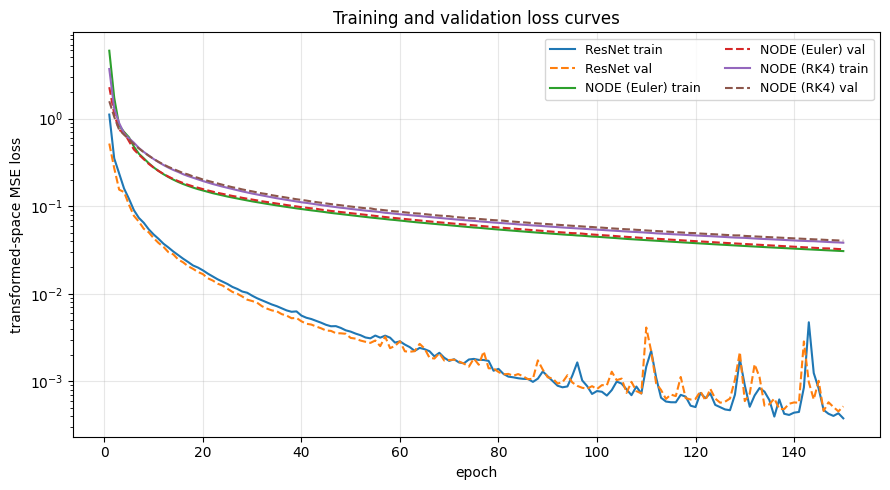

In [14]:
plt.figure(figsize=(9, 5))
for name, history_df in histories.items():
    plt.plot(history_df["epoch"], history_df["train_loss_transformed"], label=f"{MODEL_DISPLAY_NAMES[name]} train")
    plt.plot(history_df["epoch"], history_df["val_loss_transformed"], linestyle="--", label=f"{MODEL_DISPLAY_NAMES[name]} val")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("transformed-space MSE loss")
plt.title("Training and validation loss curves")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

path = RESULTS_DIR / "training_validation_losses.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Compare predicted trajectories on a few test samples

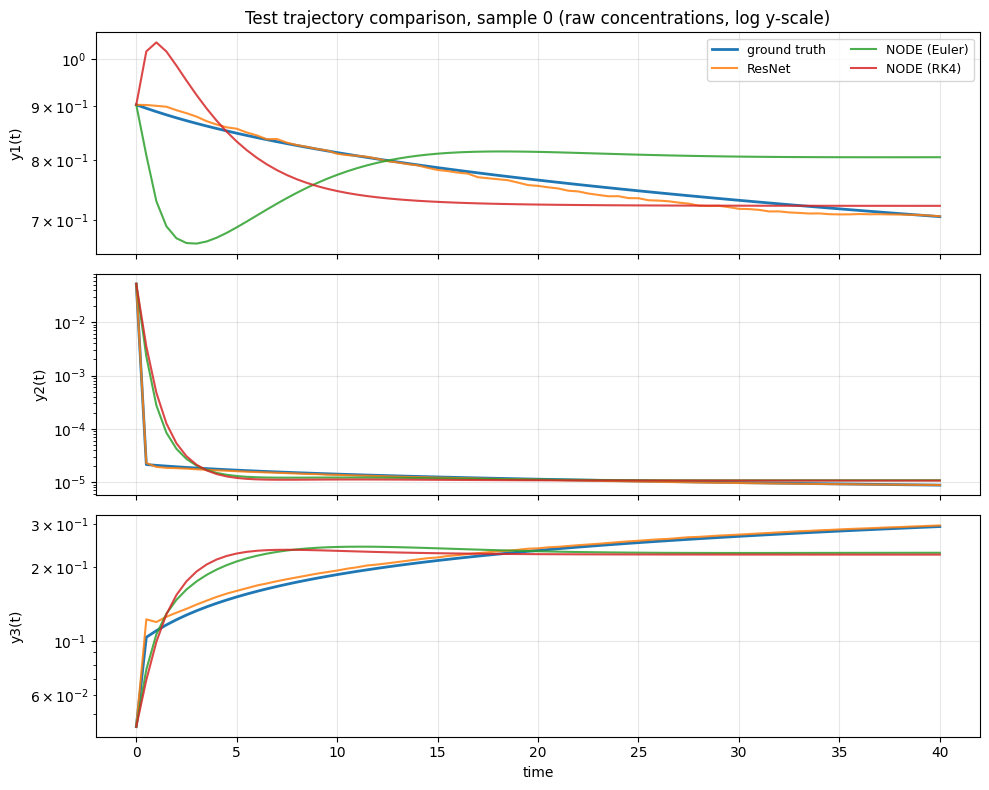

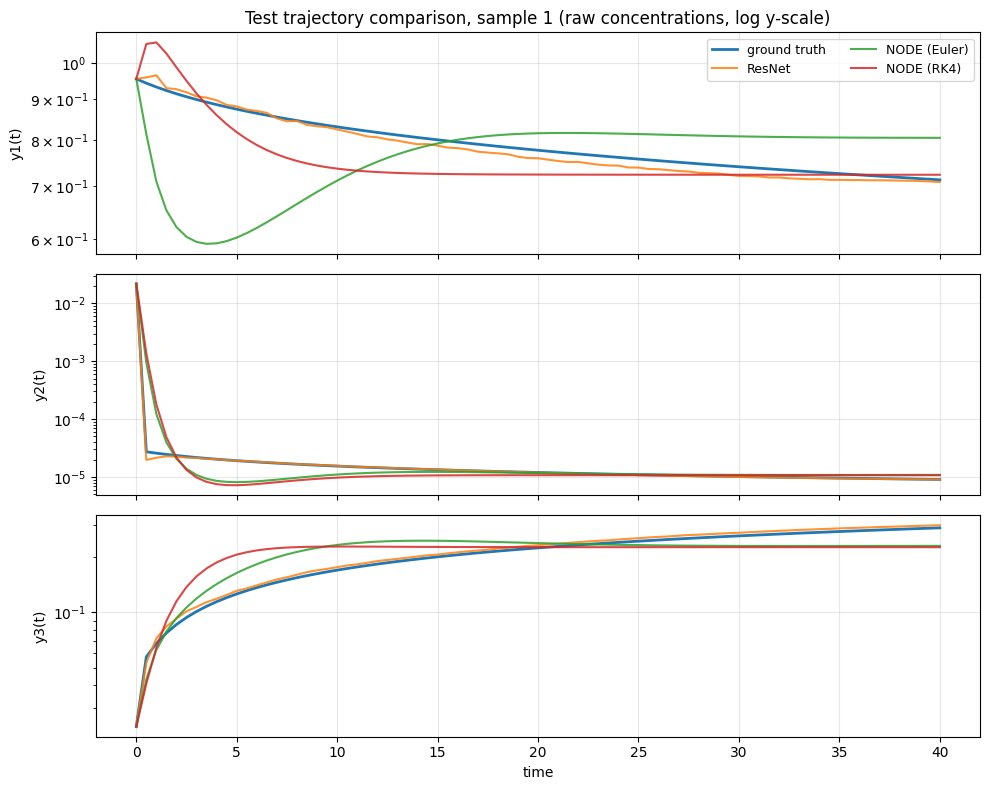

In [15]:
sample_indices = [0, 1]

for idx in sample_indices:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    true_traj_raw = test_traj_raw[idx]

    for j in range(3):
        axes[j].plot(T_EVAL, true_traj_raw[:, j], linewidth=2, label="ground truth")

    for name, pred_log in test_predictions_log.items():
        pred_raw = inverse_transform(pred_log[idx])
        for j in range(3):
            axes[j].plot(T_EVAL, pred_raw[:, j], label=MODEL_DISPLAY_NAMES[name], alpha=0.85)

    labels = ["y1(t)", "y2(t)", "y3(t)"]
    for j in range(3):
        axes[j].set_ylabel(labels[j])
        axes[j].set_yscale("log")
        axes[j].grid(True, alpha=0.3)

    axes[0].set_title(f"Test trajectory comparison, sample {idx} (raw concentrations, log y-scale)")
    axes[0].legend(ncol=2, fontsize=9)
    axes[-1].set_xlabel("time")

    plt.tight_layout()
    path = RESULTS_DIR / f"trajectory_comparison_sample_{idx}.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


## Transformed-space comparison on the stiff component $y_2$

This is the central transformed-space diagnostic for the Robertson study. Because $y_2$ occupies a very small scale in raw coordinates, raw-space plots alone can hide important discrepancies. The transformed-space $y_2$ comparison therefore acts as the sharpest stress test among the plotted diagnostics in this notebook.


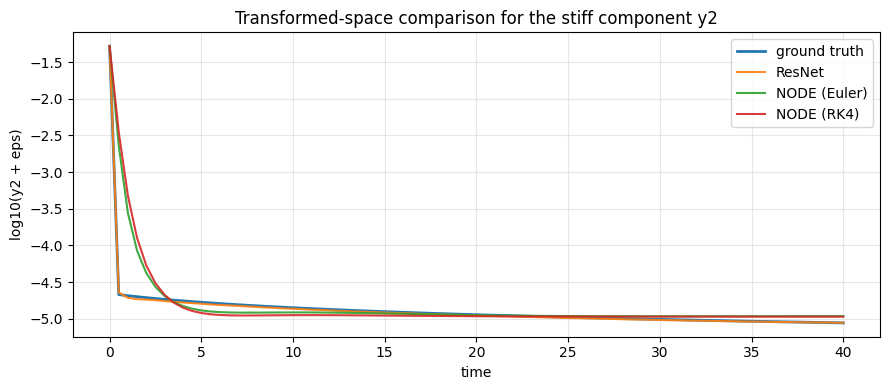

In [16]:
idx = 0
component_idx = 1
all_curves = [test_traj_log[idx, :, component_idx]]
all_curves.extend(pred_log[idx, :, component_idx] for pred_log in test_predictions_log.values())
all_curves = np.stack(all_curves, axis=0)
ymin = float(all_curves.min())
ymax = float(all_curves.max())
padding = 0.05 * max(ymax - ymin, 1e-6)

plt.figure(figsize=(9, 4))
plt.plot(T_EVAL, test_traj_log[idx, :, component_idx], linewidth=2, label="ground truth")

for name in ["resnet", "node_euler", "node_rk4"]:
    plt.plot(
        T_EVAL,
        get_transformed_component_series(test_predictions_log[name], component_idx=component_idx)[idx],
        label=MODEL_DISPLAY_NAMES[name],
        alpha=0.9,
    )

plt.ylim(ymin - padding, ymax + padding)
plt.xlabel("time")
plt.ylabel("log10(y2 + eps)")
plt.title("Transformed-space comparison for the stiff component y2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

path = RESULTS_DIR / "y2_transformed_space_comparison.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Parameter count versus test loss

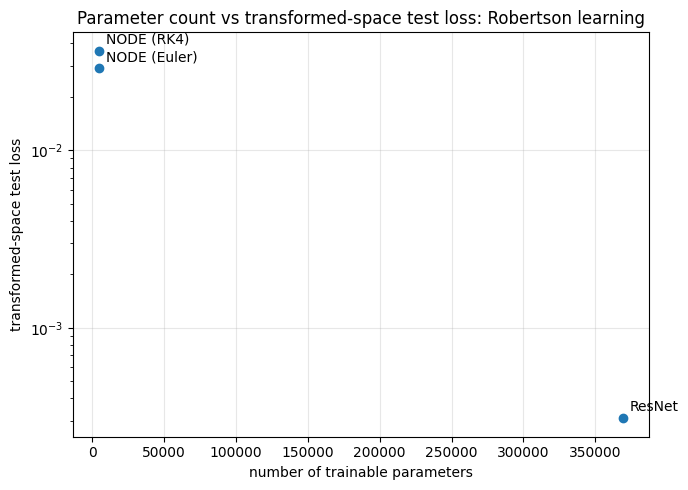

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(summary_df["parameter_count"], summary_df["transformed_space_test_loss"])

for _, row in summary_df.iterrows():
    plt.annotate(row["display_name"], (row["parameter_count"], row["transformed_space_test_loss"]), xytext=(5, 5), textcoords="offset points")

plt.yscale("log")
plt.xlabel("number of trainable parameters")
plt.ylabel("transformed-space test loss")
plt.title("Parameter count vs transformed-space test loss: Robertson learning")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "parameters_vs_test_loss.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Save raw prediction arrays

In [18]:
np.save(RESULTS_DIR / "test_t_eval.npy", T_EVAL)
np.save(RESULTS_DIR / "test_ground_truth_raw.npy", test_traj_raw)
np.save(RESULTS_DIR / "test_ground_truth_log.npy", test_traj_log)
np.save(RESULTS_DIR / "test_ground_truth_y2_log.npy", get_transformed_component_series(test_traj_log, component_idx=1))

for name, pred_log in test_predictions_log.items():
    np.save(RESULTS_DIR / f"{name}_test_predictions_log.npy", pred_log)
    np.save(RESULTS_DIR / f"{name}_test_predictions_raw.npy", inverse_transform(pred_log))
    np.save(
        RESULTS_DIR / f"{name}_test_predictions_y2_log.npy",
        get_transformed_component_series(pred_log, component_idx=1),
    )

print("Saved raw arrays.")


Saved raw arrays.
